In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

In [2]:
url = "https://raw.githubusercontent.com/haneenhasan10/AI-Driven-Customer-Retention-Strategy-for-Banking/main/Data/Bank%20Customer%20Churn%20Prediction.csv"
df = pd.read_csv(url)
df.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [3]:
print("----------- Dataset Info -----------")
print(df.info())

----------- Dataset Info -----------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  object 
 3   gender            10000 non-null  object 
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 937.6+ KB
None


In [4]:
print("----------- Missing Values -----------")
print(df.isnull().sum())

----------- Missing Values -----------
customer_id         0
credit_score        0
country             0
gender              0
age                 0
tenure              0
balance             0
products_number     0
credit_card         0
active_member       0
estimated_salary    0
churn               0
dtype: int64


In [5]:
print("---------- Summary Statistics ----------")
print(df.describe())

---------- Summary Statistics ----------
        customer_id  credit_score           age        tenure        balance  \
count  1.000000e+04  10000.000000  10000.000000  10000.000000   10000.000000   
mean   1.569094e+07    650.528800     38.921800      5.012800   76485.889288   
std    7.193619e+04     96.653299     10.487806      2.892174   62397.405202   
min    1.556570e+07    350.000000     18.000000      0.000000       0.000000   
25%    1.562853e+07    584.000000     32.000000      3.000000       0.000000   
50%    1.569074e+07    652.000000     37.000000      5.000000   97198.540000   
75%    1.575323e+07    718.000000     44.000000      7.000000  127644.240000   
max    1.581569e+07    850.000000     92.000000     10.000000  250898.090000   

       products_number  credit_card  active_member  estimated_salary  \
count     10000.000000  10000.00000   10000.000000      10000.000000   
mean          1.530200      0.70550       0.515100     100090.239881   
std           0.581654

In [6]:
print("-----Unique values for each catogrical columns------")
cols_to_check = ['country','gender']
for col in df[cols_to_check]:
  print(df[col].unique())

-----Unique values for each catogrical columns------
['France' 'Spain' 'Germany']
['Female' 'Male']


In [7]:
df_final= df.copy()# make a copy
df = df.drop('customer_id', axis=1)# Drop customer_id as it's useless for prediction


/tmp/ipykernel_36432/4205089500.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='churn', data=df, palette='viridis')


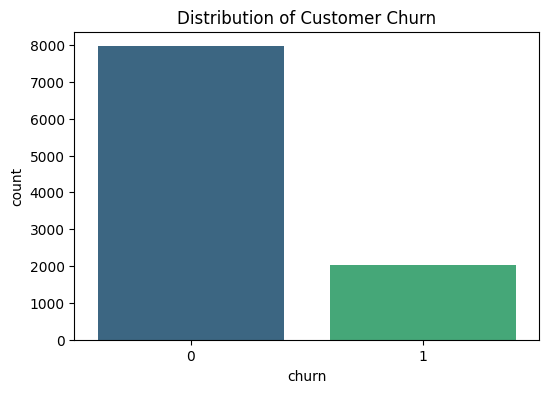

In [8]:
# Visualizing the Target Variable (Churn)

plt.figure(figsize=(6, 4))
sns.countplot(x='churn', data=df, palette='viridis')
plt.title('Distribution of Customer Churn')
plt.show()

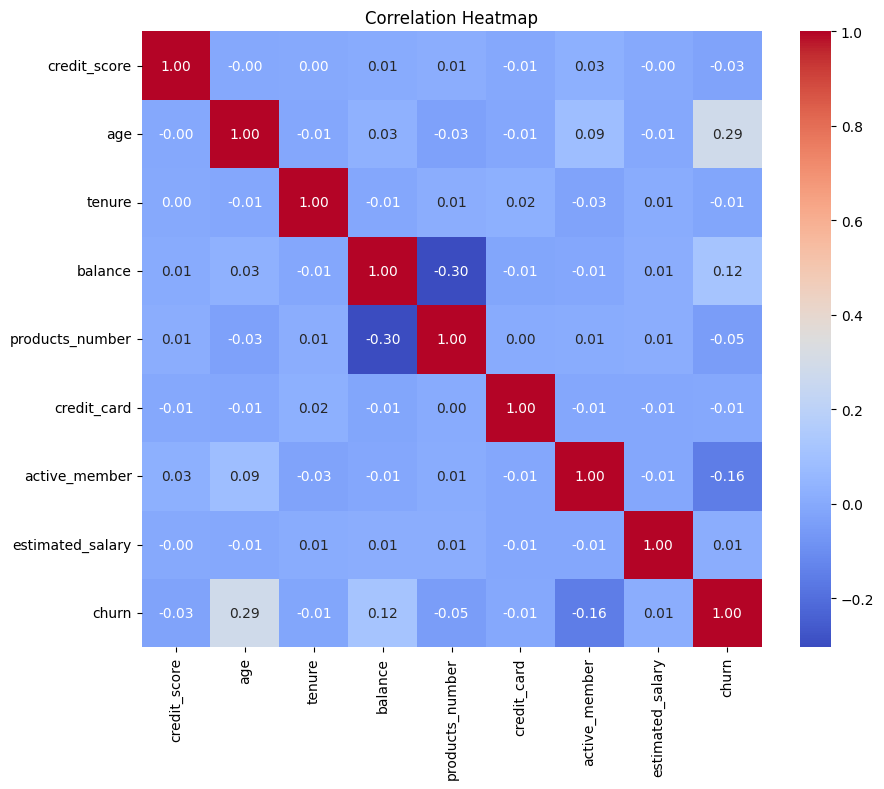

In [9]:
# Correlation Matrix: Helps us see which numerical variables relate to each other
plt.figure(figsize=(10, 8))
numeric_df = df.select_dtypes(include=['float64', 'int64'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

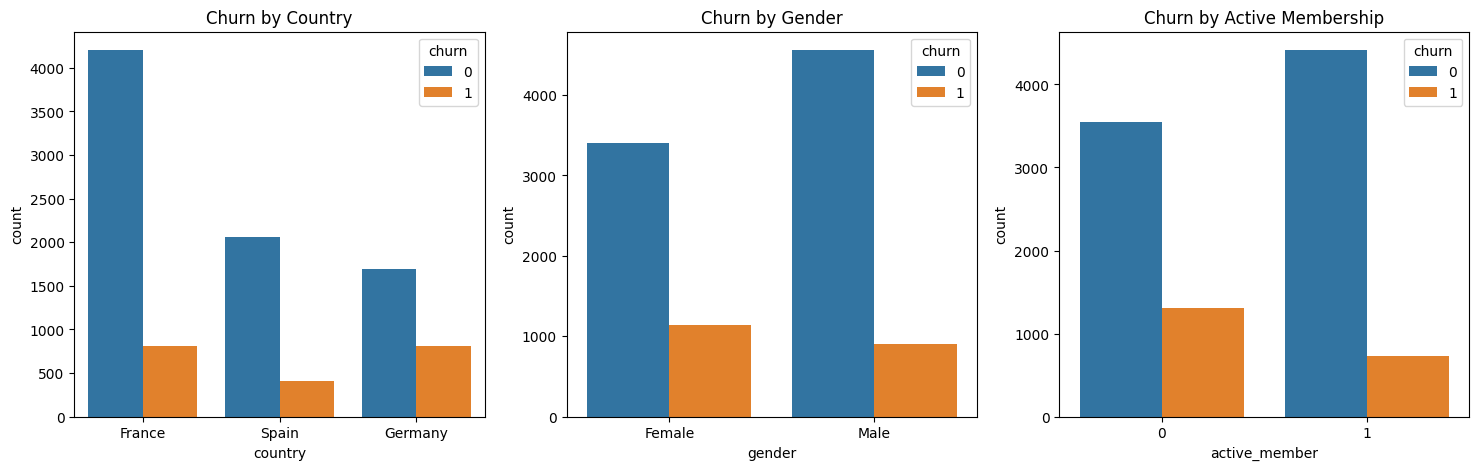

In [10]:
# Analyzing Categorical Features vs Churn
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.countplot(x='country', hue='churn', data=df, ax=axes[0])
axes[0].set_title('Churn by Country')

sns.countplot(x='gender', hue='churn', data=df, ax=axes[1])
axes[1].set_title('Churn by Gender')

sns.countplot(x='active_member', hue='churn', data=df, ax=axes[2])
axes[2].set_title('Churn by Active Membership')

plt.show()

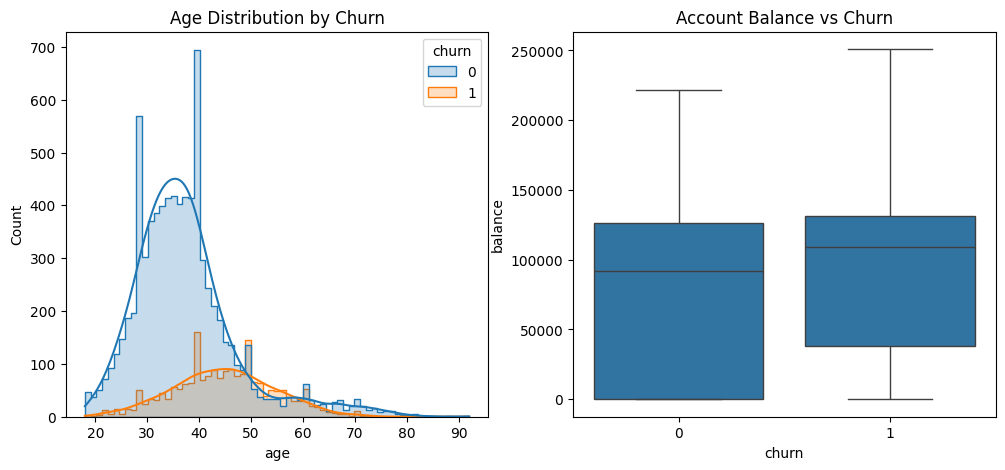

In [11]:
#  Numerical Distributions (Age & Balance)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(data=df, x='age', hue='churn', kde=True, element="step")
plt.title('Age Distribution by Churn')

plt.subplot(1, 2, 2)
sns.boxplot(x='churn', y='balance', data=df)
plt.title('Account Balance vs Churn')

plt.show()

In [12]:
# LabelEncoder
le = LabelEncoder()
df['country'] = le.fit_transform(df['country'])
df['gender'] = le.fit_transform(df['gender'])

In [13]:
# Split Data
X = df.drop(['churn'], axis=1) # drop the target
y = df['churn']               # the target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

In [14]:
# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [15]:
# Defining Classification Models
models = {
    "Random Forest Classifier": RandomForestClassifier(n_estimators=200, random_state=42),
    "LightGBM Classifier": LGBMClassifier(n_estimators=200, learning_rate=0.1, verbose=-1)
}

# Training and Evaluation
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print(f"\n======= {name} =======")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.2%}")
    print("\nDetailed Report:")
    print(classification_report(y_test, y_pred))


======= Random Forest Classifier =======
Accuracy: 85.95%

Detailed Report:
              precision    recall  f1-score   support

           0       0.87      0.96      0.92      1593
           1       0.76      0.45      0.57       407

    accuracy                           0.86      2000
   macro avg       0.82      0.71      0.74      2000
weighted avg       0.85      0.86      0.84      2000


======= LightGBM Classifier =======
Accuracy: 85.60%

Detailed Report:
              precision    recall  f1-score   support

           0       0.88      0.95      0.91      1593
           1       0.72      0.48      0.58       407

    accuracy                           0.86      2000
   macro avg       0.80      0.72      0.75      2000
weighted avg       0.85      0.86      0.84      2000



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [16]:
# Defining Classification Models using imbalance handling methods
models = {
    "Random Forest Classifier": RandomForestClassifier(
        n_estimators=200,class_weight='balanced', random_state=42),
    # add: class_weight= 'balanced'
    "LightGBM Classifier": LGBMClassifier(
        n_estimators=200,is_unbalance=True, learning_rate=0.1, verbose=-1)
    # add: is_unbalance=True
}

# Training and Evaluation
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print(f"\n======= {name} =======")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.2%}")
    print("\nDetailed Report:")
    print(classification_report(y_test, y_pred))


======= Random Forest Classifier =======
Accuracy: 85.60%

Detailed Report:
              precision    recall  f1-score   support

           0       0.87      0.96      0.91      1593
           1       0.76      0.43      0.55       407

    accuracy                           0.86      2000
   macro avg       0.81      0.70      0.73      2000
weighted avg       0.85      0.86      0.84      2000


======= LightGBM Classifier =======
Accuracy: 82.30%

Detailed Report:
              precision    recall  f1-score   support

           0       0.91      0.86      0.89      1593
           1       0.55      0.67      0.60       407

    accuracy                           0.82      2000
   macro avg       0.73      0.76      0.75      2000
weighted avg       0.84      0.82      0.83      2000



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


/tmp/ipykernel_36432/3837919712.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=feature_importance, palette='magma')


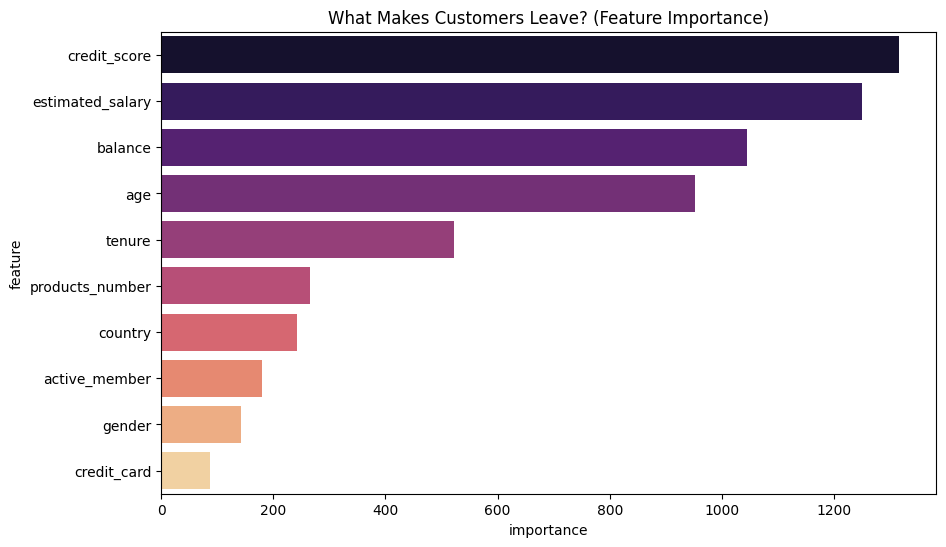

In [17]:
##Feature Importance\ LightGBM
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': models["LightGBM Classifier"].feature_importances_
}).sort_values(by='importance', ascending=False)


plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=feature_importance, palette='magma')
plt.title('What Makes Customers Leave? (Feature Importance)')
plt.show()

In [18]:
# scale all data
X_all_scaled = scaler.transform(X)

# calculate Churn_Probability
df_final['Churn_Probability'] = model.predict_proba(X_all_scaled)[:, 1]

#calculate Churn_Prediction
df_final['Churn_Prediction'] = model.predict(X_all_scaled)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [19]:
# convert numerical values to text
df_final.loc[df_final['churn'] == 1, 'churn_label'] = 'Exited'
df_final.loc[df_final['churn'] == 0, 'churn_label'] = 'Stayed'

df_final.loc[df_final['Churn_Prediction'] == 1, 'prediction_label'] = 'Predicted to Churn'
df_final.loc[df_final['Churn_Prediction'] == 0, 'prediction_label'] = 'Predicted to Stay'

if 'active_member' in df_final.columns:
    df_final['active_status'] = df_final['active_member'].astype(str)
    df_final.loc[df_final['active_member'] == 1, 'active_status'] = 'Active'
    df_final.loc[df_final['active_member'] == 0, 'active_status'] = 'Inactive'

In [20]:
from google.colab import files
output_name = 'Bank_Churn.csv'
df_final.to_csv(output_name, index=False)

files.download(output_name)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>